# Shortest Path / Depth Bridge Comparison

This notebook builds the cross-group comparison directly from the saved results inside `shortest-path-dijkstra-train-2-4-6.ipynb` and `shortest-path-dijkstra-train-10-14.ipynb`.

No checkpoint loading, no data generation, and no re-evaluation are needed.

In [1]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
personal_token = user_secrets.get_secret("GITHUB_TOKEN")

!rm -rf transformer-analyzing
!git clone https://{personal_token}@github.com/maximvw/transformer-analyzing.git transformer-analyzing
%cd transformer-analyzing

import html
import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

PYTHON = sys.executable
print("Python:", sys.executable)
print("CUDA available:", torch.cuda.is_available())
print("CUDA devices:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"GPU {i}: {props.name} | {props.total_memory / 1e9:.1f} GB")

ROOT = Path.cwd()
print("ROOT:", ROOT)

CKPT_DIR = ROOT / "checkpoints" / "shortest_path_dijkstra_full_n10"
print("CKPT_DIR:", CKPT_DIR)


Cloning into 'transformer-analyzing'...
remote: Enumerating objects: 561, done.
remote: Counting objects: 100% (223/223), done.
remote: Compressing objects: 100% (173/173), done.
remote: Total 561 (delta 85), reused 164 (delta 48), pack-reused 338 (from 1)
Receiving objects: 100% (561/561), 17.71 MiB | 26.91 MiB/s, done.
Resolving deltas: 100% (232/232), done.
/kaggle/working/transformer-analyzing
Python: /usr/bin/python3
CUDA available: False
CUDA devices: 0
ROOT: /kaggle/working/transformer-analyzing
CKPT_DIR: /kaggle/working/transformer-analyzing/checkpoints/shortest_path_dijkstra_full_n10


## Checkpoints bootstrap

Run the next cell if you want to restore the saved Kaggle artifacts and plot training curves from `train_log.json`. The quality graphs below do not depend on this step.

In [2]:
!gdown https://drive.google.com/uc?id=1rxwEQq-8QW5gN0lGKsksKGI9A3hkdhj- -O checkpoints.zip
!unzip -o checkpoints.zip


Downloading...
From (original): https://drive.google.com/uc?id=1rxwEQq-8QW5gN0lGKsksKGI9A3hkdhj-
From (redirected): https://drive.google.com/uc?id=1rxwEQq-8QW5gN0lGKsksKGI9A3hkdhj-&confirm=t&uuid=79ccc448-b37a-47eb-8390-8dd0a15ffc90
To: /kaggle/working/transformer-analyzing/checkpoints.zip
100%|████████████████████████████████████████| 346M/346M [00:04<00:00, 83.3MB/s]
Archive:  checkpoints.zip
   creating: checkpoints/
  inflating: checkpoints/.DS_Store   
  inflating: __MACOSX/checkpoints/._.DS_Store  
   creating: checkpoints/shortest_path_dijkstra_full_n10/
  inflating: __MACOSX/checkpoints/._shortest_path_dijkstra_full_n10  
   creating: checkpoints/shortest_path_dijkstra_full_n10/dijkstra_aux_4L_lambda0.1/
  inflating: __MACOSX/checkpoints/shortest_path_dijkstra_full_n10/._dijkstra_aux_4L_lambda0.1  
   creating: checkpoints/shortest_path_dijkstra_full_n10/dijkstra_sft_4L/
  inflating: __MACOSX/checkpoints/shortest_path_dijkstra_full_n10/._dijkstra_sft_4L  
   creating: checkpoin

## Training curves

These plots are built from the saved `train_log.json` files in the downloaded checkpoint folders.

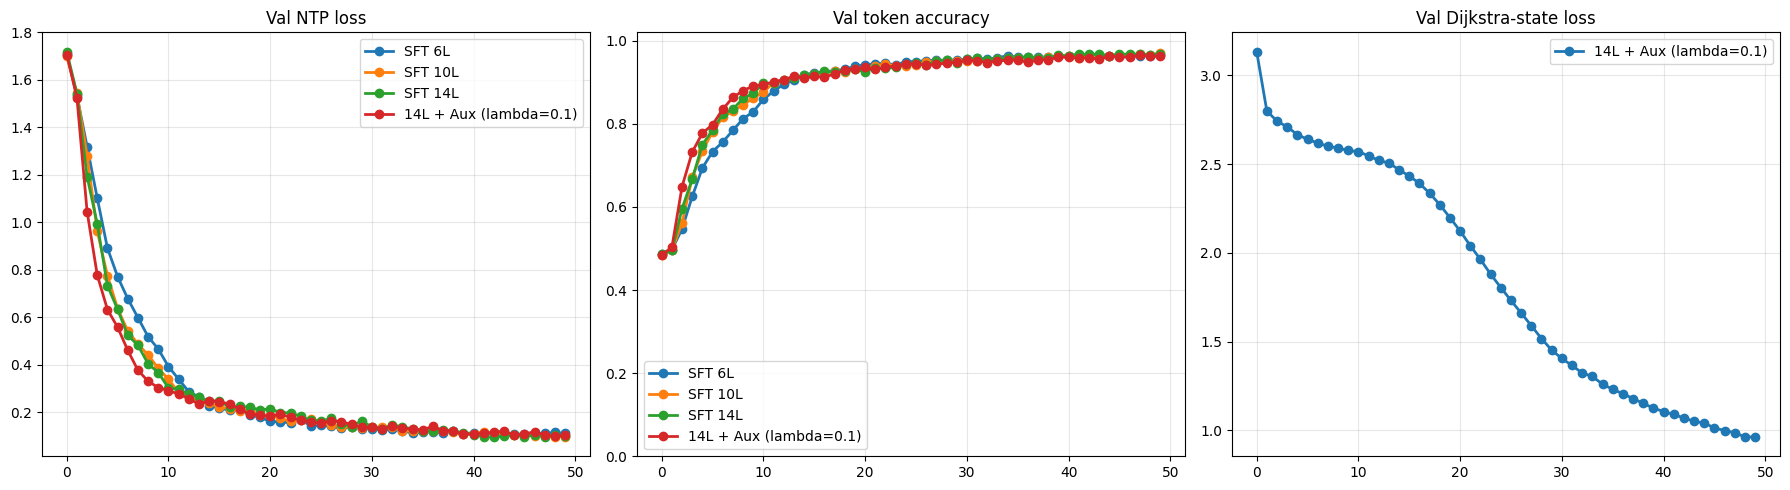

In [3]:
def load_log(path: Path):
    with open(path) as f:
        return json.load(f)

selected_for_curves = ['SFT 6L', 'SFT 10L', 'SFT 14L', '14L + Aux (lambda=0.1)']


def checkpoint_subdir(model_name: str) -> str:
    if model_name.startswith("SFT "):
        depth = model_name.split()[1].replace("L", "")
        return f"dijkstra_sft_{depth}L"
    depth = model_name.split("L", 1)[0]
    lam = model_name.split("lambda=")[1].rstrip(")")
    return f"dijkstra_aux_{depth}L_lambda{lam}"

logs = {}
missing_logs = []
for model_name in selected_for_curves:
    log_path = CKPT_DIR / checkpoint_subdir(model_name) / "train_log.json"
    if log_path.exists():
        logs[model_name] = load_log(log_path)
    else:
        missing_logs.append(str(log_path))

if missing_logs:
    raise FileNotFoundError("Missing train logs:" + "".join(missing_logs))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for label, log in logs.items():
    epochs = [row["epoch"] for row in log]
    axes[0].plot(epochs, [row["val"]["loss_main"] for row in log], marker="o", linewidth=2, label=label)
    axes[1].plot(epochs, [row["val"]["token_accuracy"] for row in log], marker="o", linewidth=2, label=label)
    if any(row["val"]["loss_state"] > 0 for row in log):
        axes[2].plot(epochs, [row["val"]["loss_state"] for row in log], marker="o", linewidth=2, label=label)

axes[0].set_title("Val NTP loss")
axes[1].set_title("Val token accuracy")
axes[1].set_ylim(0.0, 1.02)
axes[2].set_title("Val Dijkstra-state loss")
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()


In [4]:
split_order = ['test_id', 'test_ood_dense', 'test_ood_long_chain', 'test_ood_adversarial_direct', 'test_ood_equal_ties', 'test_ood_layered_bipartite', 'test_ood_near_complete_hidden_path']

split_labels = {
    "test_id": "ID",
    "test_ood_dense": "Dense",
    "test_ood_long_chain": "Long chain",
    "test_ood_adversarial_direct": "Adv. direct",
    "test_ood_equal_ties": "Equal ties",
    "test_ood_layered_bipartite": "Layered bipartite",
    "test_ood_near_complete_hidden_path": "Hidden path",
}

embedded_rows = [{'model': 'SFT 2L', 'split': 'test_id', 'exact_match': 0.5055, 'distance_accuracy': 0.90575, 'token_accuracy': 0.926864}, {'model': 'SFT 2L', 'split': 'test_ood_dense', 'exact_match': 0.661, 'distance_accuracy': 0.9527, 'token_accuracy': 0.9615}, {'model': 'SFT 2L', 'split': 'test_ood_long_chain', 'exact_match': 0.0575, 'distance_accuracy': 0.6614, 'token_accuracy': 0.7985}, {'model': 'SFT 2L', 'split': 'test_ood_adversarial_direct', 'exact_match': 0.014, 'distance_accuracy': 0.6076, 'token_accuracy': 0.7831}, {'model': 'SFT 2L', 'split': 'test_ood_equal_ties', 'exact_match': 0.9895, 'distance_accuracy': 0.999, 'token_accuracy': 0.999}, {'model': 'SFT 2L', 'split': 'test_ood_layered_bipartite', 'exact_match': 0.8655, 'distance_accuracy': 0.986, 'token_accuracy': 0.9873}, {'model': 'SFT 2L', 'split': 'test_ood_near_complete_hidden_path', 'exact_match': 0.0055, 'distance_accuracy': 0.5533, 'token_accuracy': 0.7574}, {'model': '2L + Aux (lambda=0.1)', 'split': 'test_id', 'exact_match': 0.1535, 'distance_accuracy': 0.7889, 'token_accuracy': 0.8256}, {'model': '2L + Aux (lambda=0.1)', 'split': 'test_ood_dense', 'exact_match': 0.318, 'distance_accuracy': 0.8767, 'token_accuracy': 0.8936}, {'model': '2L + Aux (lambda=0.1)', 'split': 'test_ood_long_chain', 'exact_match': 0.0115, 'distance_accuracy': 0.5736, 'token_accuracy': 0.7178}, {'model': '2L + Aux (lambda=0.1)', 'split': 'test_ood_adversarial_direct', 'exact_match': 0.0015, 'distance_accuracy': 0.4929, 'token_accuracy': 0.6823}, {'model': '2L + Aux (lambda=0.1)', 'split': 'test_ood_equal_ties', 'exact_match': 0.831, 'distance_accuracy': 0.9816, 'token_accuracy': 0.9835}, {'model': '2L + Aux (lambda=0.1)', 'split': 'test_ood_layered_bipartite', 'exact_match': 0.5715, 'distance_accuracy': 0.9494, 'token_accuracy': 0.9536}, {'model': '2L + Aux (lambda=0.1)', 'split': 'test_ood_near_complete_hidden_path', 'exact_match': 0.003, 'distance_accuracy': 0.5609, 'token_accuracy': 0.7144}, {'model': 'SFT 6L', 'split': 'test_id', 'exact_match': 0.7075, 'distance_accuracy': 0.9516, 'token_accuracy': 0.9611}, {'model': 'SFT 6L', 'split': 'test_ood_dense', 'exact_match': 0.862, 'distance_accuracy': 0.9835, 'token_accuracy': 0.9853}, {'model': 'SFT 6L', 'split': 'test_ood_long_chain', 'exact_match': 0.1655, 'distance_accuracy': 0.7537, 'token_accuracy': 0.85}, {'model': 'SFT 6L', 'split': 'test_ood_adversarial_direct', 'exact_match': 0.1015, 'distance_accuracy': 0.7433, 'token_accuracy': 0.8437}, {'model': 'SFT 6L', 'split': 'test_ood_equal_ties', 'exact_match': 0.9755, 'distance_accuracy': 0.9972, 'token_accuracy': 0.9975}, {'model': 'SFT 6L', 'split': 'test_ood_layered_bipartite', 'exact_match': 0.9725, 'distance_accuracy': 0.9972, 'token_accuracy': 0.9975}, {'model': 'SFT 6L', 'split': 'test_ood_near_complete_hidden_path', 'exact_match': 0.0385, 'distance_accuracy': 0.7096, 'token_accuracy': 0.7934}, {'model': 'SFT 10L', 'split': 'test_id', 'exact_match': 0.753, 'distance_accuracy': 0.96005, 'token_accuracy': 0.9655}, {'model': 'SFT 10L', 'split': 'test_ood_dense', 'exact_match': 0.892, 'distance_accuracy': 0.9872, 'token_accuracy': 0.9885}, {'model': 'SFT 10L', 'split': 'test_ood_long_chain', 'exact_match': 0.213, 'distance_accuracy': 0.7957, 'token_accuracy': 0.837}, {'model': 'SFT 10L', 'split': 'test_ood_adversarial_direct', 'exact_match': 0.074, 'distance_accuracy': 0.7187, 'token_accuracy': 0.7521}, {'model': 'SFT 10L', 'split': 'test_ood_equal_ties', 'exact_match': 0.9995, 'distance_accuracy': 1.0, 'token_accuracy': 1.0}, {'model': 'SFT 10L', 'split': 'test_ood_layered_bipartite', 'exact_match': 0.9845, 'distance_accuracy': 0.9984, 'token_accuracy': 0.9986}, {'model': 'SFT 10L', 'split': 'test_ood_near_complete_hidden_path', 'exact_match': 0.0305, 'distance_accuracy': 0.7167, 'token_accuracy': 0.7507}, {'model': 'SFT 14L', 'split': 'test_id', 'exact_match': 0.754, 'distance_accuracy': 0.9608, 'token_accuracy': 0.9647}, {'model': 'SFT 14L', 'split': 'test_ood_dense', 'exact_match': 0.81, 'distance_accuracy': 0.9761, 'token_accuracy': 0.9781}, {'model': 'SFT 14L', 'split': 'test_ood_long_chain', 'exact_match': 0.183, 'distance_accuracy': 0.7765, 'token_accuracy': 0.801}, {'model': 'SFT 14L', 'split': 'test_ood_adversarial_direct', 'exact_match': 0.0735, 'distance_accuracy': 0.7255, 'token_accuracy': 0.7539}, {'model': 'SFT 14L', 'split': 'test_ood_equal_ties', 'exact_match': 0.983, 'distance_accuracy': 0.9983, 'token_accuracy': 0.9985}, {'model': 'SFT 14L', 'split': 'test_ood_layered_bipartite', 'exact_match': 0.988, 'distance_accuracy': 0.9988, 'token_accuracy': 0.9989}, {'model': 'SFT 14L', 'split': 'test_ood_near_complete_hidden_path', 'exact_match': 0.0, 'distance_accuracy': 0.4925, 'token_accuracy': 0.5386}, {'model': '14L + Aux (lambda=0.1)', 'split': 'test_id', 'exact_match': 0.7215, 'distance_accuracy': 0.9559, 'token_accuracy': 0.961}, {'model': '14L + Aux (lambda=0.1)', 'split': 'test_ood_dense', 'exact_match': 0.877, 'distance_accuracy': 0.9852, 'token_accuracy': 0.9869}, {'model': '14L + Aux (lambda=0.1)', 'split': 'test_ood_long_chain', 'exact_match': 0.211, 'distance_accuracy': 0.7869, 'token_accuracy': 0.8183}, {'model': '14L + Aux (lambda=0.1)', 'split': 'test_ood_adversarial_direct', 'exact_match': 0.084, 'distance_accuracy': 0.7431, 'token_accuracy': 0.7827}, {'model': '14L + Aux (lambda=0.1)', 'split': 'test_ood_equal_ties', 'exact_match': 0.9975, 'distance_accuracy': 0.9998, 'token_accuracy': 0.9998}, {'model': '14L + Aux (lambda=0.1)', 'split': 'test_ood_layered_bipartite', 'exact_match': 0.98, 'distance_accuracy': 0.998, 'token_accuracy': 0.9982}, {'model': '14L + Aux (lambda=0.1)', 'split': 'test_ood_near_complete_hidden_path', 'exact_match': 0.036, 'distance_accuracy': 0.7368, 'token_accuracy': 0.7678}]

df_all = pd.DataFrame(embedded_rows)
df_all["split"] = pd.Categorical(df_all["split"], categories=split_order, ordered=True)
print("Embedded rows:", len(df_all))
df_all.head()


Embedded rows: 42


,model,split,exact_match,distance_accuracy,token_accuracy
0,SFT 2L,test_id,0.5055,0.90575,0.926864
1,SFT 2L,test_ood_dense,0.6610,0.95270,0.961500
2,SFT 2L,test_ood_long_chain,0.0575,0.66140,0.798500
3,SFT 2L,test_ood_adversarial_direct,0.0140,0.60760,0.783100
4,SFT 2L,test_ood_equal_ties,0.9895,0.99900,0.999000


In [5]:
selected_models = [
    "SFT 6L",
    "SFT 10L",
    "SFT 14L",
    "14L + Aux (lambda=0.1)",
]

bridge_df = df_all[df_all["model"].isin(selected_models)].copy()
bridge_df = bridge_df.sort_values(["model", "split"])
bridge_df


,model,split,exact_match,distance_accuracy,token_accuracy
35,14L + Aux (lambda=0.1),test_id,0.7215,0.95590,0.9610
36,14L + Aux (lambda=0.1),test_ood_dense,0.8770,0.98520,0.9869
37,14L + Aux (lambda=0.1),test_ood_long_chain,0.2110,0.78690,0.8183
38,14L + Aux (lambda=0.1),test_ood_adversarial_direct,0.0840,0.74310,0.7827
39,14L + Aux (lambda=0.1),test_ood_equal_ties,0.9975,0.99980,0.9998
40,14L + Aux (lambda=0.1),test_ood_layered_bipartite,0.9800,0.99800,0.9982
41,14L + Aux (lambda=0.1),test_ood_near_complete_hidden_path,0.0360,0.73680,0.7678
21,SFT 10L,test_id,0.7530,0.96005,0.9655
22,SFT 10L,test_ood_dense,0.8920,0.98720,0.9885
23,SFT 10L,test_ood_long_chain,0.2130,0.79570,0.8370


In [6]:
exact_df = bridge_df.pivot(index="model", columns="split", values="exact_match").loc[selected_models, split_order]
distance_df = bridge_df.pivot(index="model", columns="split", values="distance_accuracy").loc[selected_models, split_order]

exact_df.columns = [split_labels[col] for col in exact_df.columns]
distance_df.columns = [split_labels[col] for col in distance_df.columns]

exact_df


,ID,Dense,Long chain,Adv. direct,Equal ties,Layered bipartite,Hidden path
model,,,,,,,
SFT 6L,0.7075,0.862,0.1655,0.1015,0.9755,0.9725,0.0385
SFT 10L,0.7530,0.892,0.2130,0.0740,0.9995,0.9845,0.0305
SFT 14L,0.7540,0.810,0.1830,0.0735,0.9830,0.9880,0.0000
14L + Aux (lambda=0.1),0.7215,0.877,0.2110,0.0840,0.9975,0.9800,0.0360


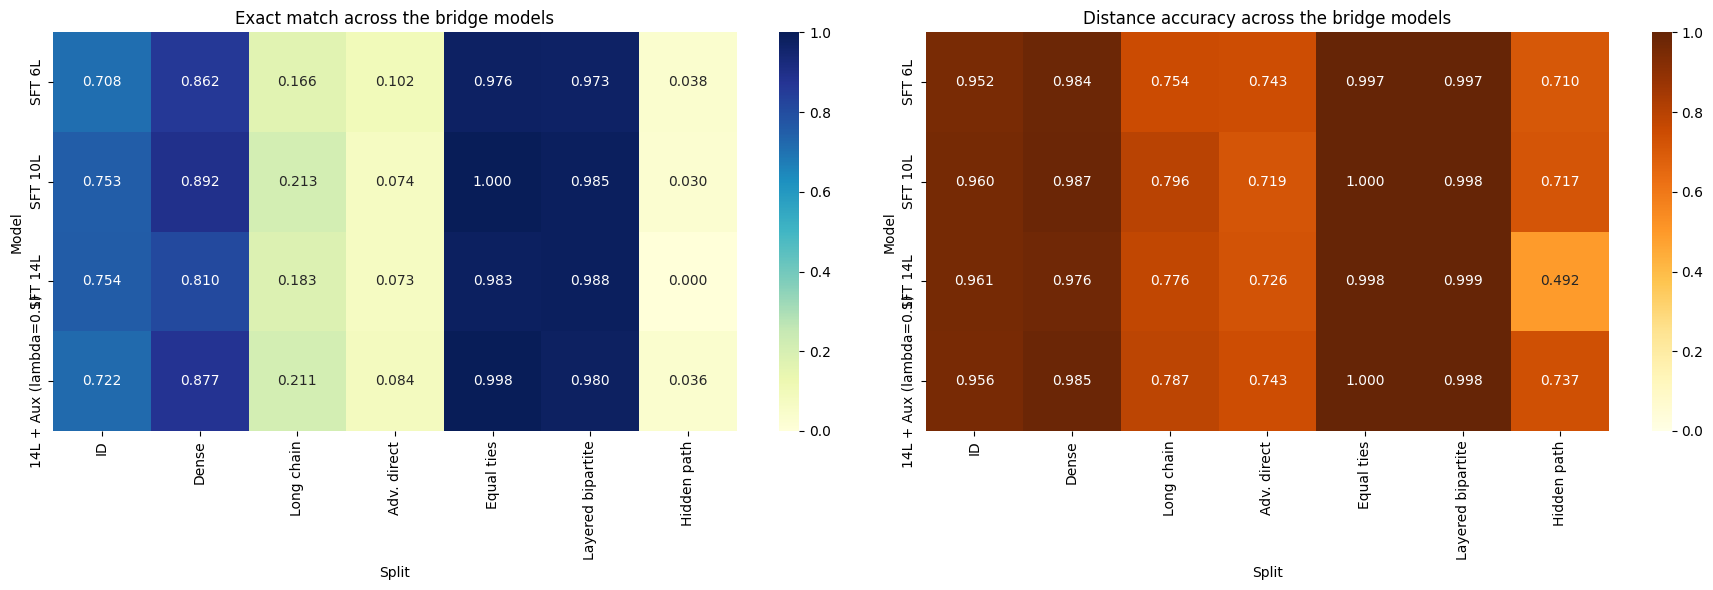

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(exact_df, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0.0, vmax=1.0, ax=axes[0])
axes[0].set_title("Exact match across the bridge models")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Model")

sns.heatmap(distance_df, annot=True, fmt=".3f", cmap="YlOrBr", vmin=0.0, vmax=1.0, ax=axes[1])
axes[1].set_title("Distance accuracy across the bridge models")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Model")

plt.tight_layout()
plt.show()


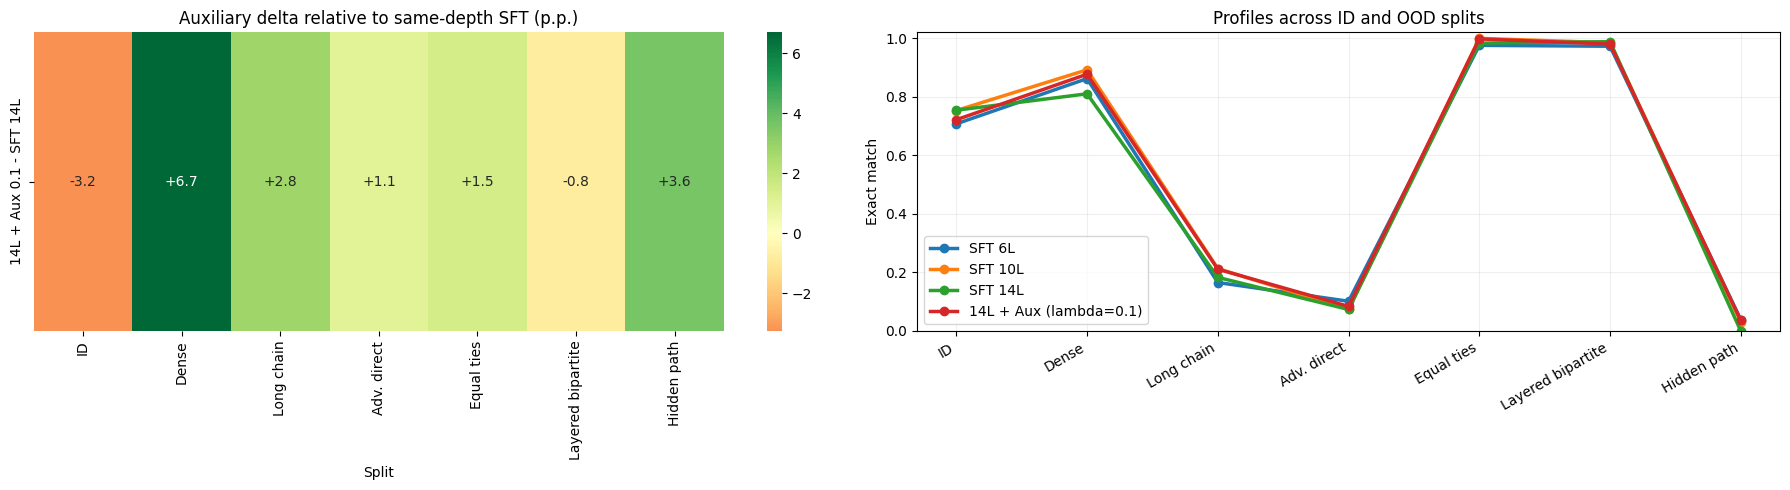

In [8]:
baseline = exact_df.loc["SFT 14L"]
aux_delta = (exact_df.loc["14L + Aux (lambda=0.1)"] - baseline) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

bridge_delta = pd.DataFrame({"14L + Aux 0.1 - SFT 14L": aux_delta}).T
sns.heatmap(bridge_delta, annot=True, fmt="+.1f", cmap="RdYlGn", center=0.0, ax=axes[0])
axes[0].set_title("Auxiliary delta relative to same-depth SFT (p.p.)")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("")

x = np.arange(len(split_order))
for model_name in selected_models:
    ys = bridge_df[bridge_df["model"] == model_name].set_index("split").loc[split_order, "exact_match"].tolist()
    axes[1].plot(x, ys, marker="o", linewidth=2.5, label=model_name)

axes[1].set_xticks(x)
axes[1].set_xticklabels([split_labels[split] for split in split_order], rotation=30, ha="right")
axes[1].set_ylim(0.0, 1.02)
axes[1].set_ylabel("Exact match")
axes[1].set_title("Profiles across ID and OOD splits")
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()
